In [1]:
import numpy as np
import pandas as pd


# Load the DATA

In [2]:
df = pd.read_csv(r"C:\Users\Ashish Kushwaha\Downloads\Software_feature_shipment_data_set.csv")

In [3]:
df.head()

,planned_shipment_date,team_size,feature_complexity,num_dependencies,sprint_length_weeks,num_blockers,holidays_in_sprint,priority_encoded,past_avg_delay_days,estimated_bug_count,delay_days
0,2021-01-17,9,8.168887,3,2,0,0,0,-0.965238,2,15
1,2021-01-24,23,6.557334,1,2,0,0,0,0.444158,6,11
2,2021-02-07,16,8.275576,1,3,0,0,1,1.645090,8,15
3,2021-02-07,18,3.938867,8,2,0,0,0,-3.751354,1,11
4,2021-02-14,21,7.361716,2,2,0,1,1,-0.958348,6,16


In [4]:
df.shape

(1300, 11)

In [9]:
df.columns

Index(['planned_shipment_date', 'team_size', 'feature_complexity',
       'num_dependencies', 'sprint_length_weeks', 'num_blockers',
       'holidays_in_sprint', 'priority_encoded', 'past_avg_delay_days',
       'estimated_bug_count', 'delay_days'],
      dtype='str')

# EDA

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   planned_shipment_date  1300 non-null   str    
 1   team_size              1300 non-null   int64  
 2   feature_complexity     1300 non-null   float64
 3   num_dependencies       1300 non-null   int64  
 4   sprint_length_weeks    1300 non-null   int64  
 5   num_blockers           1300 non-null   int64  
 6   holidays_in_sprint     1300 non-null   int64  
 7   priority_encoded       1300 non-null   int64  
 8   past_avg_delay_days    1300 non-null   float64
 9   estimated_bug_count    1300 non-null   int64  
 10  delay_days             1300 non-null   int64  
dtypes: float64(2), int64(8), str(1)
memory usage: 111.8 KB


In [11]:
df.describe()

,team_size,feature_complexity,num_dependencies,sprint_length_weeks,num_blockers,holidays_in_sprint,priority_encoded,past_avg_delay_days,estimated_bug_count,delay_days
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,13.682308,5.460658,2.995385,2.500769,0.376923,0.160769,1.129231,0.037082,5.051538,13.428462
std,6.386800,2.612645,1.735375,0.684705,0.650284,0.367459,0.682053,1.977190,2.177912,4.874274
min,3.000000,1.008365,0.000000,2.000000,0.000000,0.000000,0.000000,-6.508958,0.000000,2.000000
25%,8.000000,3.196076,2.000000,2.000000,0.000000,0.000000,1.000000,-1.324640,4.000000,10.000000
50%,14.000000,5.551511,3.000000,2.000000,0.000000,0.000000,1.000000,0.075471,5.000000,13.000000
75%,19.000000,7.721968,4.000000,3.000000,1.000000,0.000000,2.000000,1.409820,6.000000,17.000000
max,24.000000,9.999109,9.000000,4.000000,2.000000,1.000000,2.000000,6.991756,13.000000,29.000000


In [12]:
df.isnull().sum()

planned_shipment_date    0
team_size                0
feature_complexity       0
num_dependencies         0
sprint_length_weeks      0
num_blockers             0
holidays_in_sprint       0
priority_encoded         0
past_avg_delay_days      0
estimated_bug_count      0
delay_days               0
dtype: int64

### There is no null value.

In [13]:
df.duplicated().sum()

np.int64(0)

### There is no duplicate value.

In [35]:
for i in df.columns:
    print(f'Total value counts in column {i}: ')
    print(df[i].value_counts())
    print(50*"+")

Total value counts in column team_size: 
team_size
5     74
18    73
19    68
17    67
24    66
4     64
15    62
13    61
23    60
21    60
12    60
7     57
9     56
20    56
22    55
11    55
16    52
8     52
3     51
10    51
14    50
6     50
Name: count, dtype: int64
++++++++++++++++++++++++++++++++++++++++++++++++++
Total value counts in column feature_complexity: 
feature_complexity
8.168887    1
6.557334    1
8.275576    1
3.938867    1
7.361716    1
           ..
4.672614    1
5.777738    1
7.181101    1
6.983173    1
5.807080    1
Name: count, Length: 1300, dtype: int64
++++++++++++++++++++++++++++++++++++++++++++++++++
Total value counts in column num_dependencies: 
num_dependencies
3    297
2    290
4    202
1    194
5    133
6     73
0     68
7     27
8     15
9      1
Name: count, dtype: int64
++++++++++++++++++++++++++++++++++++++++++++++++++
Total value counts in column sprint_length_weeks: 
sprint_length_weeks
2    791
3    367
4    142
Name: count, dtype: int64
++++

In [18]:
type(df['planned_shipment_date'][0])     # this is string type, we have to convert it into date and time format

str

In [19]:
df["planned_shipment_date"] = pd.to_datetime(df["planned_shipment_date"])

### now create separate column for year , month and day.

In [20]:
df['year'] = df['planned_shipment_date'].dt.year
df['month'] = df['planned_shipment_date'].dt.month
df['day'] = df['planned_shipment_date'].dt.day

In [22]:
df.drop('planned_shipment_date',inplace= True,axis=1)

In [24]:
df.head()

,team_size,feature_complexity,num_dependencies,sprint_length_weeks,num_blockers,holidays_in_sprint,priority_encoded,past_avg_delay_days,estimated_bug_count,delay_days,year,month,day
0,9,8.168887,3,2,0,0,0,-0.965238,2,15,2021,1,17
1,23,6.557334,1,2,0,0,0,0.444158,6,11,2021,1,24
2,16,8.275576,1,3,0,0,1,1.645090,8,15,2021,2,7
3,18,3.938867,8,2,0,0,0,-3.751354,1,11,2021,2,7
4,21,7.361716,2,2,0,1,1,-0.958348,6,16,2021,2,14


### check outliers

In [40]:
col_to_check_outliers =  ['team_size','feature_complexity','num_dependencies','past_avg_delay_days','delay_days']
for col in col_to_check_outliers:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

team_size: 0 outliers
feature_complexity: 0 outliers
num_dependencies: 16 outliers
past_avg_delay_days: 10 outliers
delay_days: 3 outliers


In [42]:
# Now we will remove these outliers

for col in col_to_check_outliers:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


# Visualization

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

##### First of all check the outliers using boxplot.

Checking outliers for columns team_size 


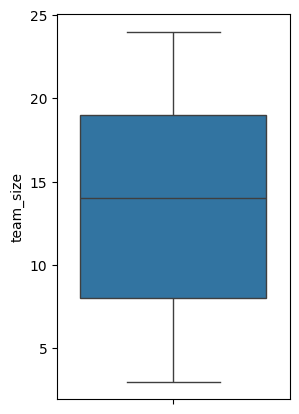

+++++++++++++++++++++++++++++++++++++++++++++


Checking outliers for columns feature_complexity 


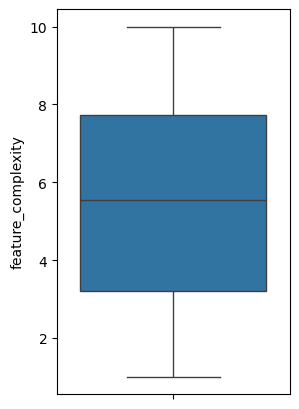

+++++++++++++++++++++++++++++++++++++++++++++


Checking outliers for columns num_dependencies 


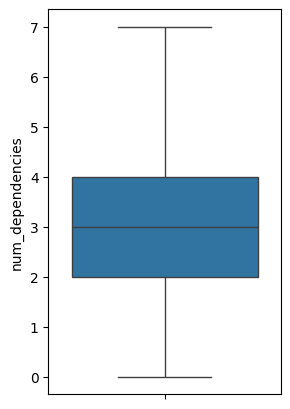

+++++++++++++++++++++++++++++++++++++++++++++


Checking outliers for columns past_avg_delay_days 


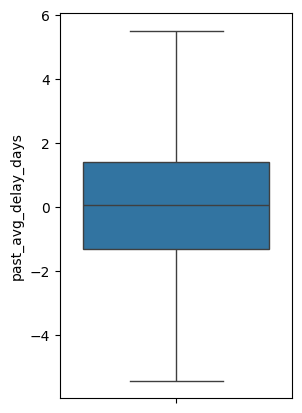

+++++++++++++++++++++++++++++++++++++++++++++


Checking outliers for columns delay_days 


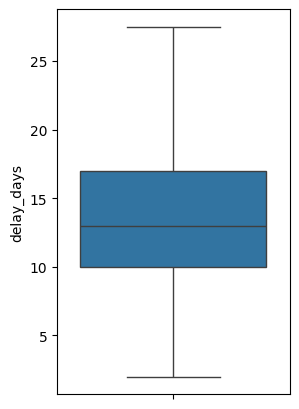

+++++++++++++++++++++++++++++++++++++++++++++




In [44]:
col_to_check_outliers =  ['team_size','feature_complexity','num_dependencies','past_avg_delay_days','delay_days']
for i in col_to_check_outliers:
    print(f'Checking outliers for columns {i} ')
    plt.figure(figsize=(3,5))
    sns.boxplot(df[i])
    plt.show()
    print(45*'+')
    print('\n')

### Now there are not any outlier , all are replaced with lower or upper values

<Axes: xlabel='delay_days', ylabel='Count'>

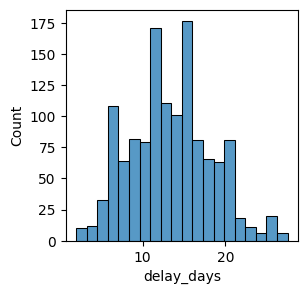

In [47]:
plt.figure(figsize= (3,3))
sns.histplot(df['delay_days'])

<Axes: xlabel='past_avg_delay_days', ylabel='Density'>

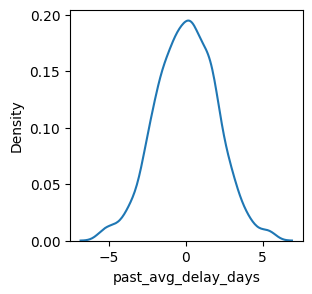

In [54]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize= (3,3))
sns.distplot(df['past_avg_delay_days'],hist=False)

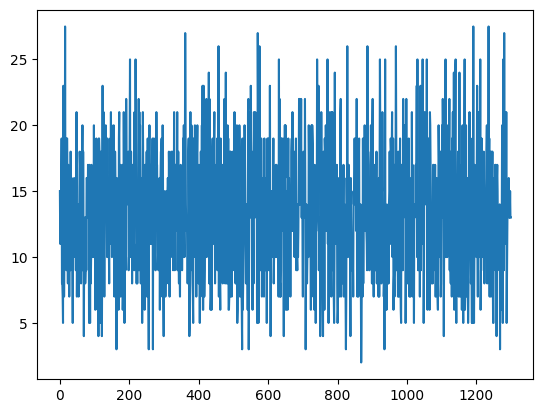

In [120]:
plt.plot(df['delay_days'])

### Correlation

<Axes: >

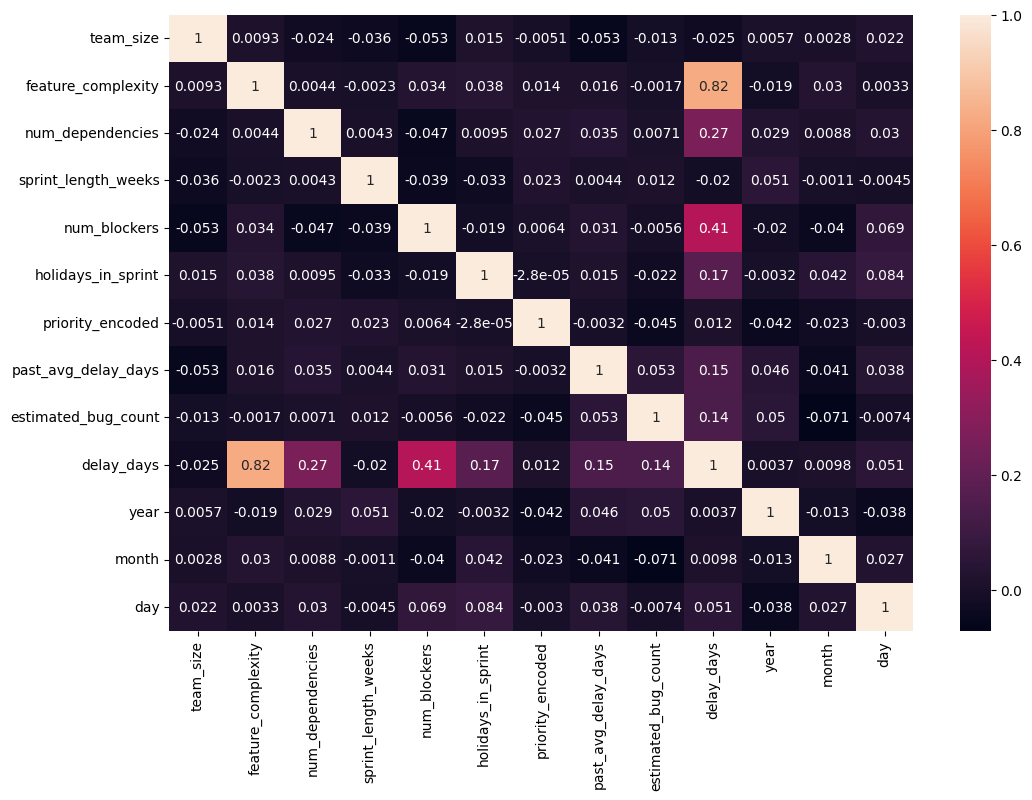

In [58]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)

# Model Training

### Train-Test Split

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X = df.drop('delay_days',axis=1)
y = df['delay_days']

In [61]:
print(X.shape)
print(y.shape)

(1300, 12)
(1300,)


In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

## Random Forest

In [63]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf = RandomForestRegressor()
rf.fit(X_train,y_train)   # Model trained here but with default parameter

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [68]:
y_pred= rf.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error

In [71]:
print("Mean Absolute Error using Random Forest Regressor is : " , mean_absolute_error(y_pred,y_test))

Mean Absolute Error using Random Forest Regressor is :  1.228403846153846


## Hyper Parameter Tuning using GridSearchCV

In [72]:
from sklearn.model_selection import GridSearchCV

In [76]:
params={"n_estimators":[100,200,300],"max_depth":[5,10,20],"min_samples_split":[2,5,10]}

grid = GridSearchCV(rf,params,cv= 5,scoring='neg_mean_absolute_error')

In [82]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [84]:
best_model=grid.best_estimator_

In [85]:
grid_pred = best_model.predict(X_test)

In [87]:
print("Mean Absolute Error by applying GridSearchCV for hyperparameter tuning : ",mean_absolute_error(grid_pred,y_test))

Mean Absolute Error by applying GridSearchCV for hyperparameter tuning :  1.2222115384615384


## Without HyperParameter Tuning , Mean Absolute Error = 1.228403846153846
## After Finding the best Parameter , Mean Absolute Error = 1.2222115384615384

# Now we will compare different different models who actually performs regression
- Linear Regression
- Decision Tree
- Gradient Boosting
- XGBoost

### Linear Regression

In [88]:
from sklearn.linear_model import LinearRegression

In [89]:
lin_reg = LinearRegression()

In [90]:
lin_reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
lin_reg_y_pred  = lin_reg.predict(X_test)
lin_reg_mae = mean_absolute_error(lin_reg_y_pred,y_test)

In [95]:
print("Mean Absolute Error by using Linear Regression is : ", mean_absolute_error(lin_reg_y_pred,y_test))

Mean Absolute Error by using Linear Regression is :  0.8775431829601285


### Decision Tree 

In [96]:
from sklearn.tree import DecisionTreeRegressor

In [99]:
dec_tree = DecisionTreeRegressor()

In [100]:
dec_tree.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [101]:
dec_tree_pred = dec_tree.predict(X_test)
dec_tree_mae = mean_absolute_error(dec_tree_pred,y_test)

In [102]:
print("Mean Absolute Error by using Decision Tree is : ", dec_tree_mae)

Mean Absolute Error by using Linear Regression is :  1.625


### Gradient Boosting


In [103]:
from sklearn.ensemble import GradientBoostingRegressor

In [104]:
gbr = GradientBoostingRegressor()

In [105]:
gbr.fit(X_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [106]:
gbr_pred = gbr.predict(X_test)

gbr_mae = mean_absolute_error(gbr_pred,y_test)

In [107]:
print("Mean Absolute Error by using Gradient Boosting is : " , gbr_mae)

Mean Absolute Error by using Gradient Boosting is :  1.0005207694006075


### XGBoost 

In [109]:
from xgboost import XGBRegressor


In [110]:
xgb = XGBRegressor()

In [111]:
xgb.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [113]:
xgb_pred = xgb.predict(X_test)
xgb_mae = mean_absolute_error(xgb_pred,y_test)

In [114]:
print("Mean Absolute Error by using XGBoost Regreesor is : " , xgb_mae)

Mean Absolute Error by using XGBoost Regreesor is :  1.1464338916998642


# Now compare all models MAE(Mean Absolute Erro)

In [115]:
models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Tuned Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

mae_scores = [
    0.877,
    1.625,
    1.228,
    1.222,
    1.000,
    1.146
]

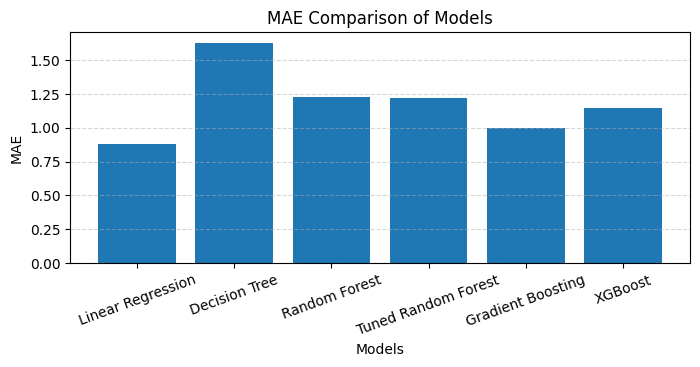

In [119]:
plt.figure(figsize=(8,3))
plt.bar(models, mae_scores)

plt.title("MAE Comparison of Models")
plt.xlabel("Models")
plt.ylabel("MAE")

plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()